## Performance Summary

Summary statistics and key insights from the benchmark data.

Loaded benchmark data from benchmark_results.json


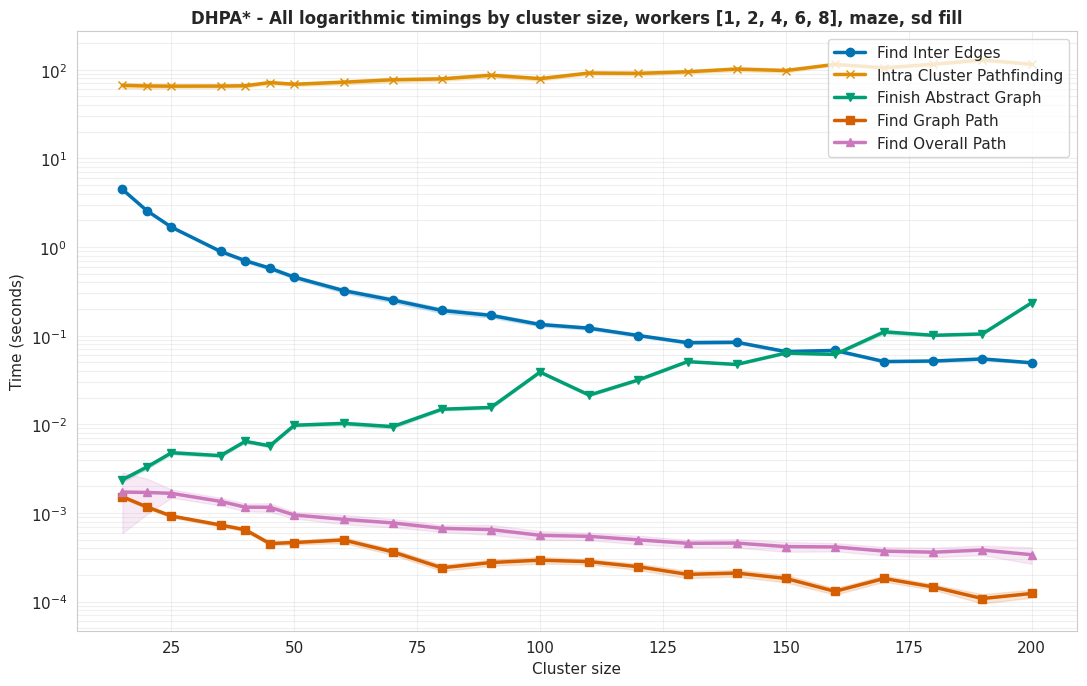

In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots with colorblind-friendly palette
sns.set_style("whitegrid")
sns.set_palette("colorblind")  # Colorblind-friendly palette
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load benchmark results
results_file = Path("benchmark_results.json")

if not results_file.exists():
    print(f"Error: {results_file} not found. Please run benchmark.py first.")
else:
    with open(results_file, "r") as f:
        results = json.load(f)
    
    print(f"Loaded benchmark data from {results_file}")

# Convert results to DataFrame
data_rows = []

for point in results['data']:
    row = {
        'cluster_size': point['cluster_size'],
        'workers_size': point.get('workers_size', 1),
        'algorithm': point['algorithm'],
        'run': point['run'],
    }
    
    # Extract and separate the nested worker_analysis dictionary
    timings = point['timings'].copy()
    worker_analysis = timings.pop('worker_analysis', {})
    
    # Add top-level timing metrics
    row.update(timings)
    
    # Flatten worker metrics into individual columns
    for k, v in worker_analysis.items():
        row[k] = v
        
    data_rows.append(row)

df = pd.DataFrame(data_rows)

# Rename columns for clarity
rename_mapping = {
    'preprocessed': 'intra cluster pathfinding',
    'inter_edges': 'find inter edges',
    'found_graph_path': 'find graph path',
    'found_overall_path': 'find overall path'
}
# Only rename columns that exist
rename_mapping = {old: new for old, new in rename_mapping.items() if old in df.columns}
df = df.rename(columns=rename_mapping)

# -------------------------------------------------------------------------
# Filter for specific worker values: 1, 2, 4, 6
# -------------------------------------------------------------------------
target_workers = [1, 2, 4, 6, 8]
df_filtered = df[df['workers_size'].isin(target_workers)]

# Plot all timing steps for each algorithm on same graph with different colors
timing_metrics = [col for col in df_filtered.columns if col not in ['cluster_size', 'workers_size', 'algorithm', 'run'] 
                  and 'memory' not in col.lower() and 'length' not in col.lower() and 'time' not in col.lower() and 'worker' not in col.lower()]

algorithms = sorted(df_filtered['algorithm'].unique())

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette("colorblind", len(timing_metrics))
colors = colorblind_palette

fig, axes = plt.subplots(1, len(algorithms), figsize=(11, 7), squeeze=False)

markers = ['o', 'x', 'v', 's', '^', '*']

for algo_idx, algo in enumerate(algorithms):
    ax = axes[0, algo_idx]
    algo_data = df_filtered[df_filtered['algorithm'] == algo]
    
    for metric_idx, metric in enumerate(timing_metrics):
        # Skip if metric doesn't exist
        if metric not in algo_data.columns:
            continue
        
        # Calculate mean and standard deviation per cluster size
        grouped = algo_data.groupby('cluster_size')[metric].agg(['mean', 'std']).reset_index()
        
        # Skip if all values are zero
        if grouped['mean'].sum() == 0:
            continue
            
        # Fill missing standard deviation values with 0 if single observation
        grouped['std'] = grouped['std'].fillna(0)
        
        # Plot mean trend line
        ax.plot(grouped['cluster_size'], grouped['mean'], marker=markers[metric_idx % len(markers)], linewidth=2.5, 
                markersize=6, color=colors[metric_idx], label=metric.replace('_', ' ').title())
        
        # Plot standard deviation shaded fill area
        # Clip the lower bound at 1e-6 to avoid log scale errors/distortion with negative numbers
        lower_bound = np.maximum(grouped['mean'] - grouped['std'], 1e-6)
        upper_bound = grouped['mean'] + grouped['std']
        ax.fill_between(grouped['cluster_size'], lower_bound, upper_bound, color=colors[metric_idx], alpha=0.15)
    
    ax.set_xlabel('Cluster size', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'{algo.upper()}* - All logarithmic timings by cluster size, workers [1, 2, 4, 6, 8], maze, sd fill', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [ ]:
# Plot total time vs cluster size
if 'pathfinding_time' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['pathfinding_time'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='o', label="Search phase time (s)", linewidth=2.5, markersize=8)
        # ax.fill_between(grouped.index, 
        #                 grouped['mean'] - grouped['std'],
        #                 grouped['mean'] + grouped['std'],
        #                 alpha=0.2)
        
        grouped = algo_data.groupby('cluster_size')['preprocessing_time'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='x', label="Preprocessing phase time (s)", linewidth=2.5, markersize=8)
        # ax.fill_between(grouped.index, 
        #                 grouped['mean'] - grouped['std'],
        #                 grouped['mean'] + grouped['std'],
        #                 alpha=0.2)
        
        grouped = algo_data.groupby('cluster_size')['max_memory'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='v', label="Max memory (MB)", linewidth=2.5, markersize=8)
        # ax.fill_between(grouped.index, 
        #                 grouped['mean'] - grouped['std'],
        #                 grouped['mean'] + grouped['std'],
        #                 alpha=0.2)
        
    ax.set_xlabel('Cluster size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=11, fontweight='bold')
    ax.set_title('DHPA* - Logarithmic select values vs cluster size, scene_mp_2p_01, average over 10 runs, 1 worker', fontsize=12, fontweight='bold')
    ax.set_ylim([1e-3, 2e2])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
    
    print("Plot: Total time vs cluster size")